In [303]:
include("visr_mod.jl")
using CSV,DataFrames,GMT

include("../src/GeoUtils.jl");
import .GeoUtils as GU

In [2]:
DataSet=CSV.read("./combined.cmm4",DataFrame,delim=' ', ignorerepeated=true, header=false)

Row,Column1,Column2,Column3,Column4,Column5,Column6,Column7,Column8
,String15,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0014_GPS,14.331,51.737,-0.54,0.13,0.13,0.13,0.0
2,0017_GPS,14.258,53.07,-0.64,0.13,-0.05,0.13,0.0
3,001A_GPS,21.153,38.631,-4.98,0.25,-17.18,0.23,0.0
4,0022_GIZ,24.173,42.225,1.34,0.26,-1.47,0.24,0.0
5,0022_GPS,14.541,52.356,-0.81,0.13,0.14,0.13,0.0
6,002A_GPS,22.74,37.589,-17.35,0.25,-26.46,0.23,0.0
7,003A_GPS,22.134,37.402,-18.3,0.33,-26.25,0.3,0.0
8,004A_GPS,22.854,37.244,-17.93,0.33,-27.19,0.3,0.0
9,007A_GPS,23.541,38.042,-15.76,0.25,-24.82,0.23,0.0


In [3]:
lonmean=mean(DataSet[:,2])
latmean=mean(DataSet[:,3])

40.30759362583592

In [4]:
x_stations=Float64[];
y_stations=Float64[];
for i in 1:size(DataSet,1)
    x_temp, y_temp = llxy(mean(DataSet[:,2]), mean(DataSet[:,3]), [DataSet[i,2]], [DataSet[i,3]])
    push!(x_stations,x_temp[1])
    push!(y_stations,y_temp[1])
end

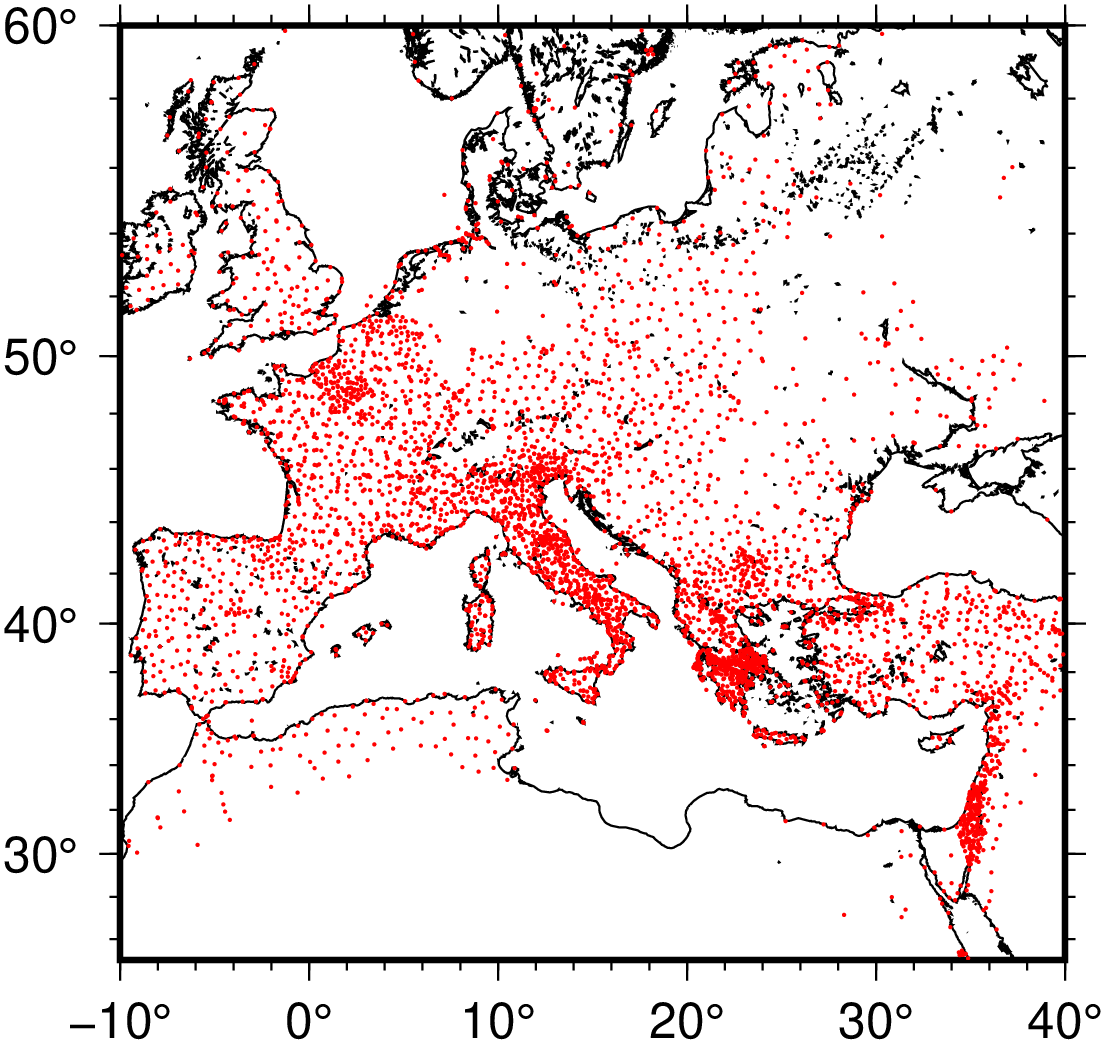

In [12]:
gmtset(MAP_FRAME_TYPE="plain")
GMT.basemap(J="M8c",region=[-10,40,25,60])
GMT.coast!(resolution = :intermediate)
GMT.scatter!(DataSet[:,2],DataSet[:,3],S="c1p",fill="red",show=true)

In [14]:
areas,indices_fallback,radii,polygons_x,polygons_y=compute_voronoi_areas(x_stations,y_stations)

([4863.607814902862, 3404.260211865345, 38.80169672360353, 404.2025037614512, 2766.940243673773, 133.9048224574217, 644.0261430049432, 52.522080403286964, 183.90295985378907, 228.00563767235872  …  64.03491315152496, 1568.4846889004111, 1437.0753252233844, 1054.7248819248634, 1527.252937347257, 305.8001665661359, 28596.574830195284, 402.4521268152166, 3250.948610516498, 880.2246532562276], [131, 157, 164, 199, 235, 244, 261, 267, 268, 269  …  5612, 5614, 5671, 5695, 5696, 5697, 5732, 5758, 5781, 5785], [20.279933963914257, 26.719265442321255, 23.93362264489971, 9.765237672680788, 9.678744670295606, 166.1823126827846, 211.16812459916582, 19.571108282040164, 18.416762508189056, 17.0638086769446  …  20.614783741462034, 374.79511719559423, 774.2699063023559, 21.264258487776885, 11.909261990744866, 23.991217765444958, 19.450996417385582, 209.32091884269528, 33.72351905159198, 23.788697849513838], [-136.9611139463026, -136.9611139463026, -136.9611139463026, -136.9611139463026, -136.961113946

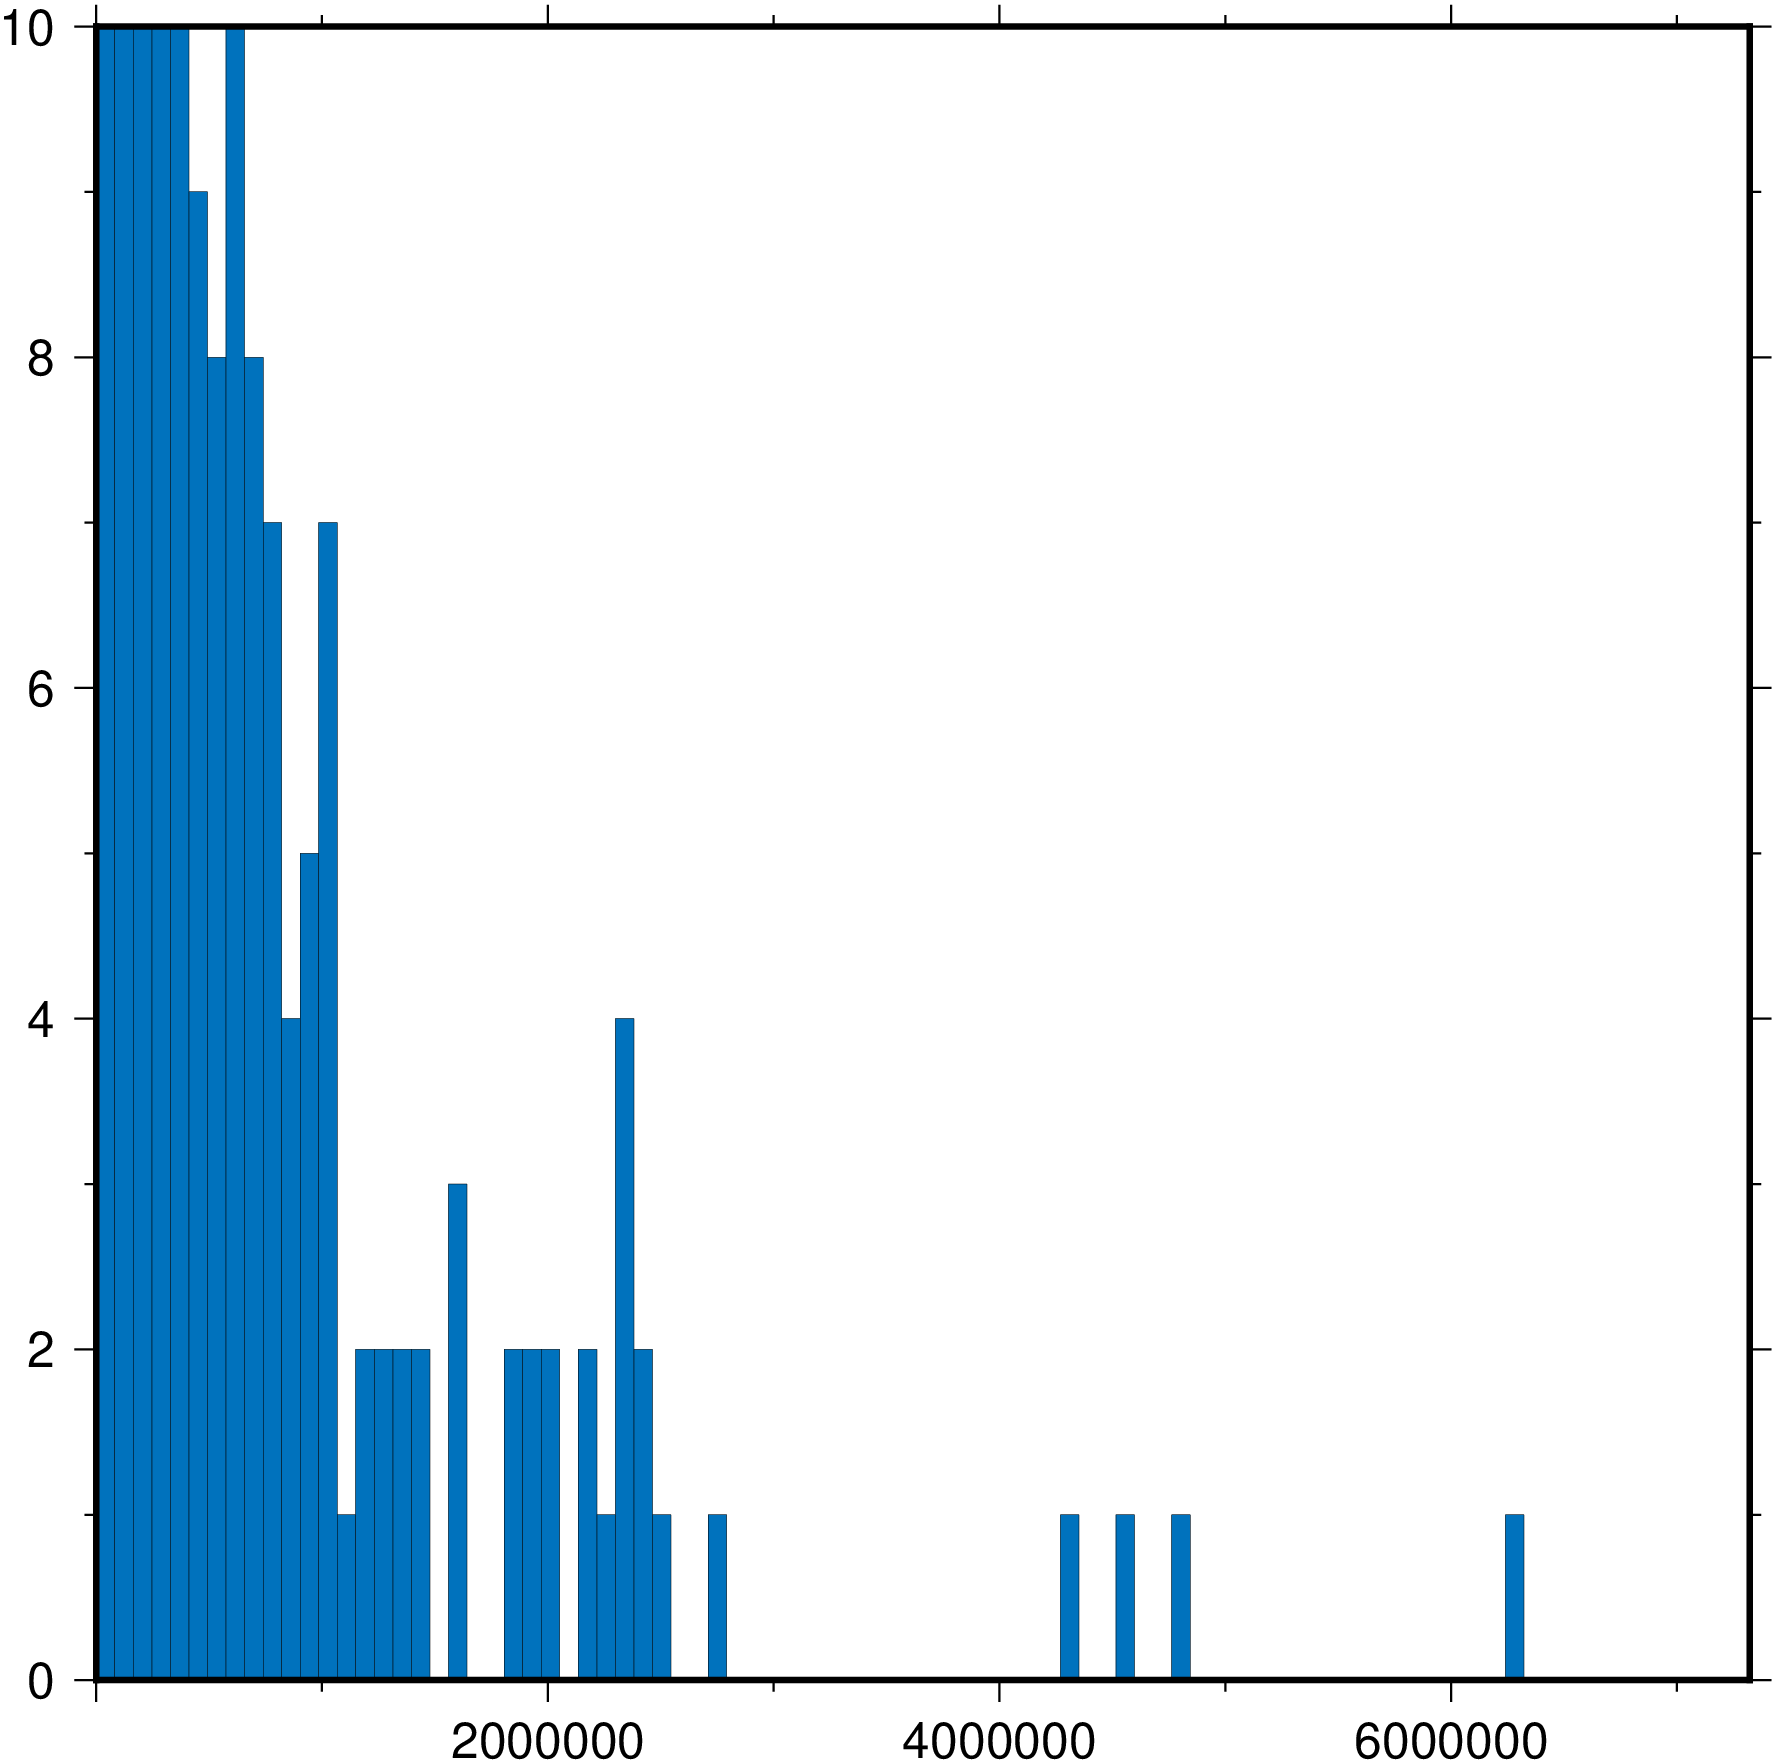

In [204]:
GMT.histogram(areas,region=[minimum(areas),maximum(areas)+10^6,0,10],show=true)

In [15]:
circles_x=Float64[]
circles_y=Float64[]

angle_range=0.0:1:360
for i=1:length(indices_fallback)
    indx=indices_fallback[i]

    x_temp=x_stations[indx]
    y_temp=y_stations[indx]
    radius_temp=radii[i]

    for angle in angle_range
        val_x=x_temp+ (radius_temp*cosd(angle))
        val_y=y_temp+ (radius_temp*sind(angle))
        push!(circles_x,val_x)
        push!(circles_y,val_y)
    end
    push!(circles_x,NaN)
    push!(circles_y,NaN)
end


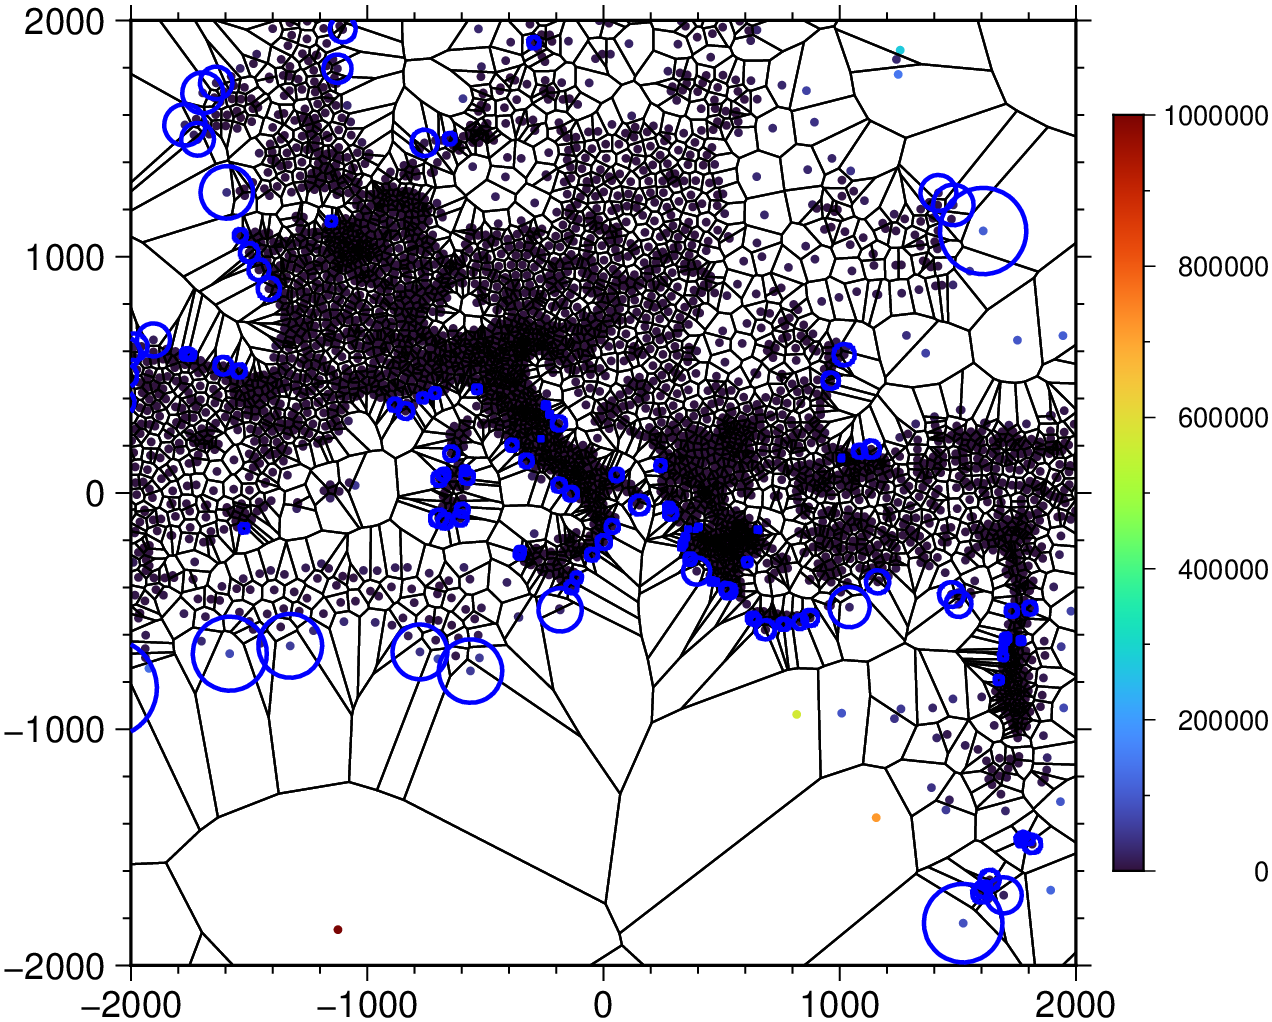

In [313]:
cpt = makecpt(cmap="turbo", range="0/1000000", D="o")
GMT.scatter(x_stations,y_stations,region=[-2000,2000,-2000,2000],J="X8c",S="c2p", zcolor=areas, cmap=cpt)
colorbar!()
GMT.plot!(polygons_x,polygons_y)
GMT.plot!(circles_x,circles_y,pen="1p,blue",show=true)
#GMT.scatter!(x_stations[indices_fallback],y_stations[indices_fallback],S="c0.1p", fill="blue",show=true)

In [24]:
stations = Vector{Station}()

for i =1:size(DataSet,1)
    temp_station=Station(DataSet[i,2],DataSet[i,3],x_stations[i],y_stations[i],DataSet[i,4],DataSet[i,5],DataSet[i,6],DataSet[i,7],areas[i])
    push!(stations,temp_station)
end

In [304]:
parameters=Parameters(lonmean,latmean,2.15,1,100,1,24)
lons,lats,results=visr_mod(parameters, stations, 25.0, 30.0, 34.0, 38.0, 0.1, 0.1)

([25.0, 25.1, 25.2, 25.3, 25.4, 25.5, 25.6, 25.7, 25.8, 25.9  …  29.1, 29.2, 29.3, 29.4, 29.5, 29.6, 29.7, 29.8, 29.9, 30.0], [34.0, 34.0, 34.0, 34.0, 34.0, 34.0, 34.0, 34.0, 34.0, 34.0  …  38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0], VisrSolution[VisrSolution(2, 0.0, 0.0, [0.0, 0.0, 0.0], 0.0, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], 0.0, 0.0, 0.0, 0.0, 0, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]), VisrSolution(2, 0.0, 0.0, [0.0, 0.0, 0.0], 0.0, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], 0.0, 0.0, 0.0, 0.0, 0, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]), VisrSolution(2, 0.0, 0.0, [0.0, 0.0, 0.0], 0.0, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], 0.0, 0.0, 0.0, 0.0, 0, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]), VisrSolution(2, 0.0, 0.0, [0

In [305]:
I2_vec=Float64[]
for i=1:length(results)
    if(results[i].status == 0)
        I2=sqrt((results[i].strain_rate[1].^2) + (2*(results[i].strain_rate[2].^2)) + (results[i].strain_rate[3].^2))
        #print(I2)
        #print('\n')
    else
        #I2=-(results[i].status)*10
        I2=0
    end
    push!(I2_vec,I2)
end

In [306]:
lon_unique=unique(lons)
lat_unique=unique(lats)

I2_matrix=reshape(I2_vec,length(lon_unique),length(lat_unique))

GU.write_to_netcdf("./ESecondInvariant.nc",lon_unique,lat_unique,I2_matrix)#nstr/yr


51×41 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  15.9313  20.677   24.9367  28.103
 0.0  0.0  0.0  0.0  0.0  0.0  0.0     20.0815  23.4417  26.4001  29.6283
 0.0  0.0  0.0  0.0  0.0  0.0  0.0     22.3793  25.1278  27.6891  30.5961
 0.0  0.0  0.0  0.0  0.0  0.0  0.0     23.8706  26.277   28.6473  31.3828
 0.0  0.0  0.0  0.0  0.0  0.0  0.0     24.2114  27.2126  29.4469  31.9904
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  24.8895  26.7493  29.9647  33.6426
 0.0  0.0  0.0  0.0  0.0  0.0  0.0     26.0665  27.3269  30.18    33.4124
 0.0  0.0  0.0  0.0  0.0  0.0  0.0     27.3865  28.9159  30.8521  34.0506
 0.0  0.0  0.0  0.0  0.0  0.0  0.0     29.3871  30.0249  32.2317  34.9413
 0.0  0.0  0.0  0.0  0.0  0.0  0.0     30.7646  31.1991  33.1254  35.7617
 ⋮                        ⋮         ⋱                              ⋮
 0.0  0.0  0.0  0.0  0.0  0.0  0.0     47.3764  48.8297  49.6364  50.1277
 0.0  0.0  0.0  0.0  0.0  0.0  0.0     44.4869  46.0746  46.9349  47.3155
 0.0  0.0  0.0  0.0  

In [173]:
output=GU.read_strain_output_visr("/Users/riccardo/Library/CloudStorage/GoogleDrive-riccardo.nucci9@gmail.com/My Drive/Work/FortranCodes/strain.out")

Lon=output.lons 
Lat=output.lats 
LonGrid=output.longrid 
LatGrid=output.latgrid 
ExxGrid=output.exx     # matrice (N_lon × N_lat) dello strain exx
ExyGrid=output.exy         # matrice (N_lon × N_lat) dello strain exx
EyyGrid=output.eyy     # matrice (N_lon × N_lat) dello strain exx

ESecondInvariantFORTRAN=sqrt.(ExxGrid.^2+EyyGrid.^2+2*ExyGrid.^2);

GU.write_to_netcdf("./ESecondInvariantFORTRAN.nc",Lon,Lat,ESecondInvariantFORTRAN)#nstr/yr

2001×801 Matrix{Float64}:
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  …  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  …  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
   ⋮                        ⋮            ⋱         ⋮                        ⋮
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  Na

In [307]:
my_design=Matrix{Float64}[]
for i in 1:length(results)
    if (sqrt((results[i].strain_rate[1].^2) + (2*(results[i].strain_rate[2].^2)) + (results[i].strain_rate[3].^2)) > (600)) & (results[i].status==0)
        my_design=results[i].design
    end
end

In [308]:
my_design

82×6 Matrix{Float64}:
 1.98789   0.0         15.6243    49.6297    0.0      49.6297
 0.0       1.95038      0.0       15.3295   48.6933  -15.3295
 2.31449   0.0       -351.457     98.5274    0.0      98.5274
 0.0       2.17834      0.0     -330.783    92.7317  330.783
 0.583863  0.0        -86.1795    27.747     0.0      27.747
 0.0       0.652553     0.0      -96.3183   31.0114   96.3183
 1.33772   0.0        -85.3913   143.501     0.0     143.501
 0.0       1.56067      0.0      -99.6232  167.418    99.6232
 0.910184  0.0        -27.2951   118.243     0.0     118.243
 0.0       1.01132      0.0      -30.3279  131.381    30.3279
 ⋮                                                     ⋮
 0.0       4.60917      0.0     -268.451   161.802   268.451
 0.240891  0.0         19.1519    40.6759    0.0      40.6759
 0.0       0.361336     0.0       28.7279   61.0138  -28.7279
 0.135474  0.0         21.5028    13.0735    0.0      13.0735
 0.0       0.129408     0.0       20.54     12.4881  -20.5

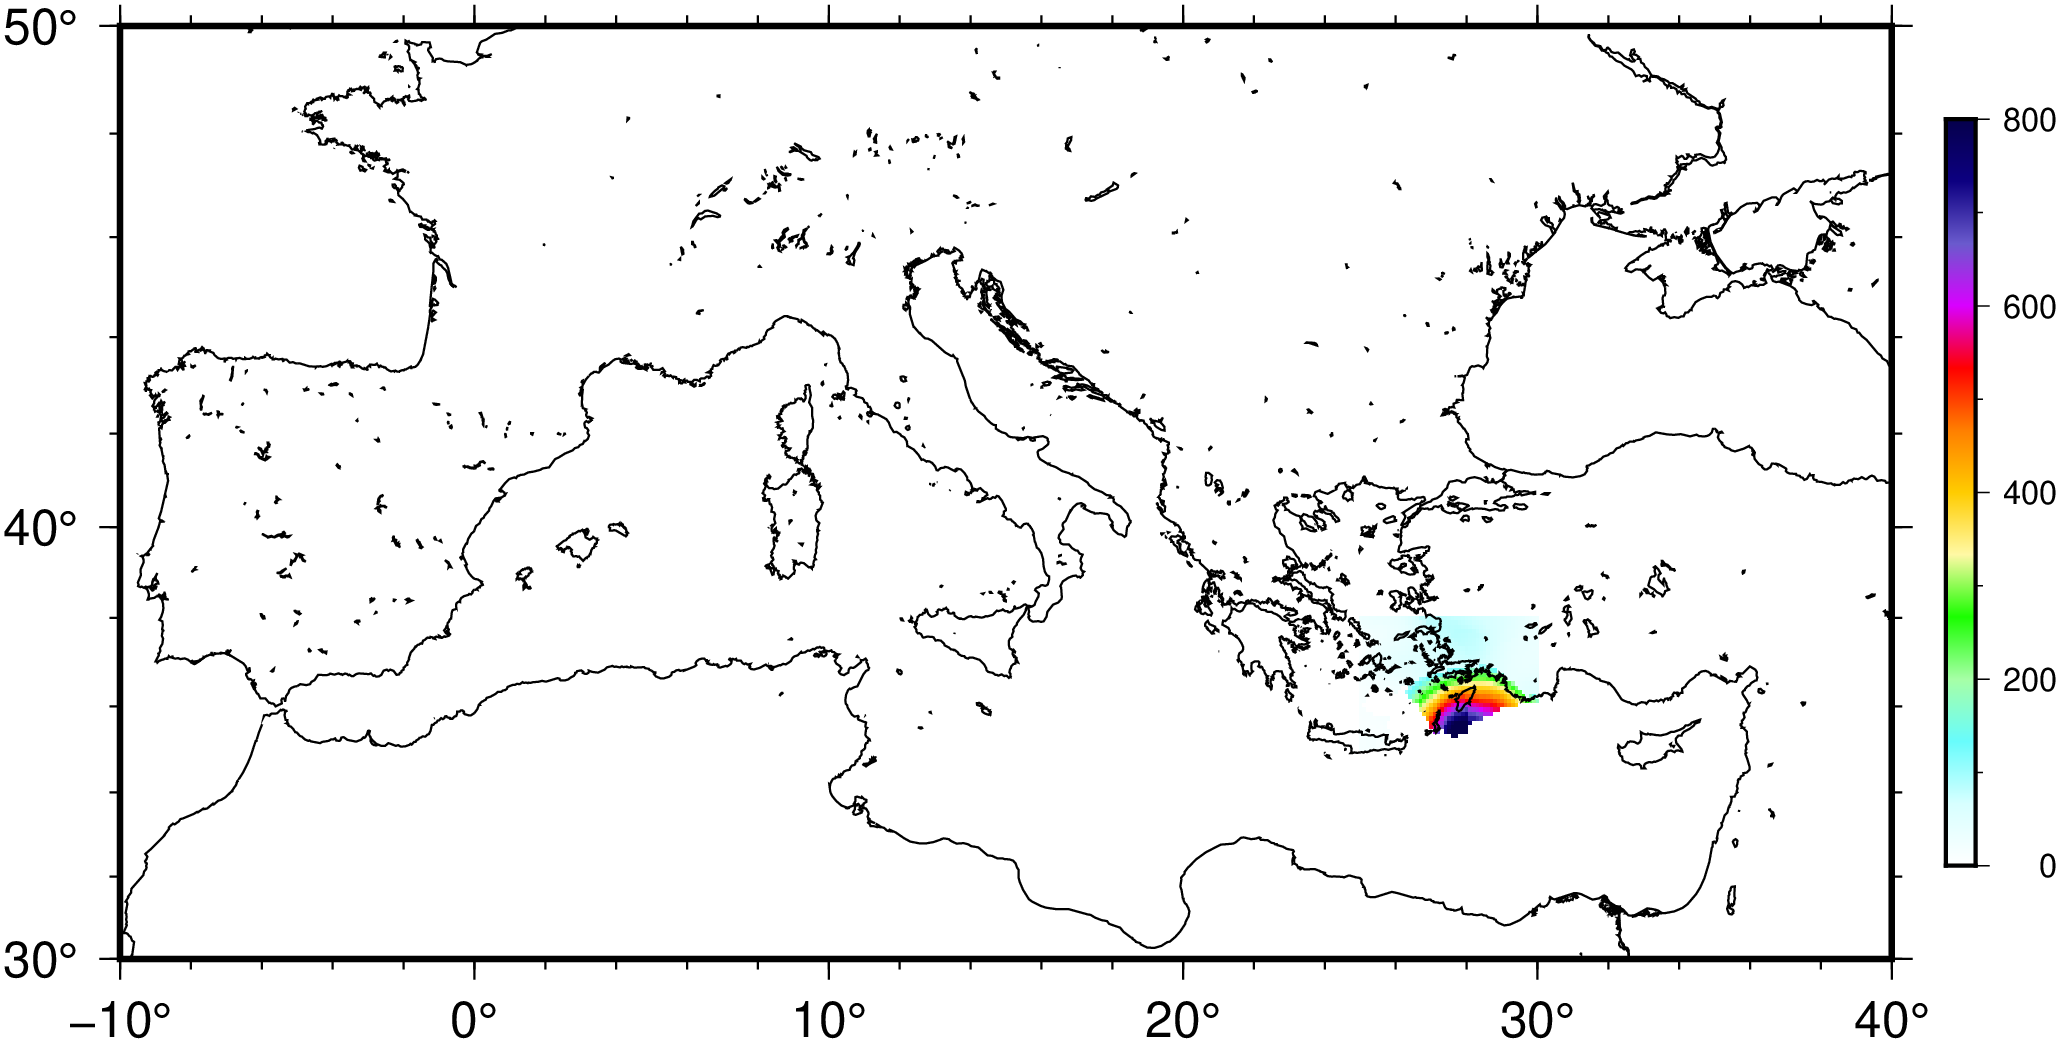

5802-element Vector{Float64}:
 51.737
 53.07
 38.631
 42.225
 52.356
 37.589
 37.402
 37.244
 38.042
 38.113
  ⋮
 47.8287
 41.8664
 47.4208
 44.969
 40.736
 55.6993
 50.8231
 49.6867
 46.8914

In [309]:
region=[-10.0, 40.0, 30.0, 50.0]
gmtset(MAP_FRAME_TYPE="plain", PROJ_LENGTH_UNIT="c")
cpt = makecpt(cmap="./STRrate.cpt", range="0/800")
GMT.basemap(region=region,J="M15c")
GMT.grdimage!("./ESecondInvariant.nc", cmap=cpt,n="n")
GMT.colorbar!()
GMT.coast!(show=true)
#GMT.velo!([DataSet[:,2] DataSet[:,3] DataSet[:,4] DataSet[:,6] DataSet[:,5] DataSet[:,7]],Se="0.05/0.95",pen="0.012c,black")
#GMT.scatter!(DataSet[DataSet[:,5].<0.07,2],DataSet[DataSet[:,5].<0.07,3],S="c4p", fill="green")
lontext=DataSet[:,2] .+ (rand(length(DataSet[:,2])).*0.1)
lattext=DataSet[:,3]
#GMT.text!(x=lontext,y=lattext, String.(DataSet[:,1]),font="4p,white",show=true)

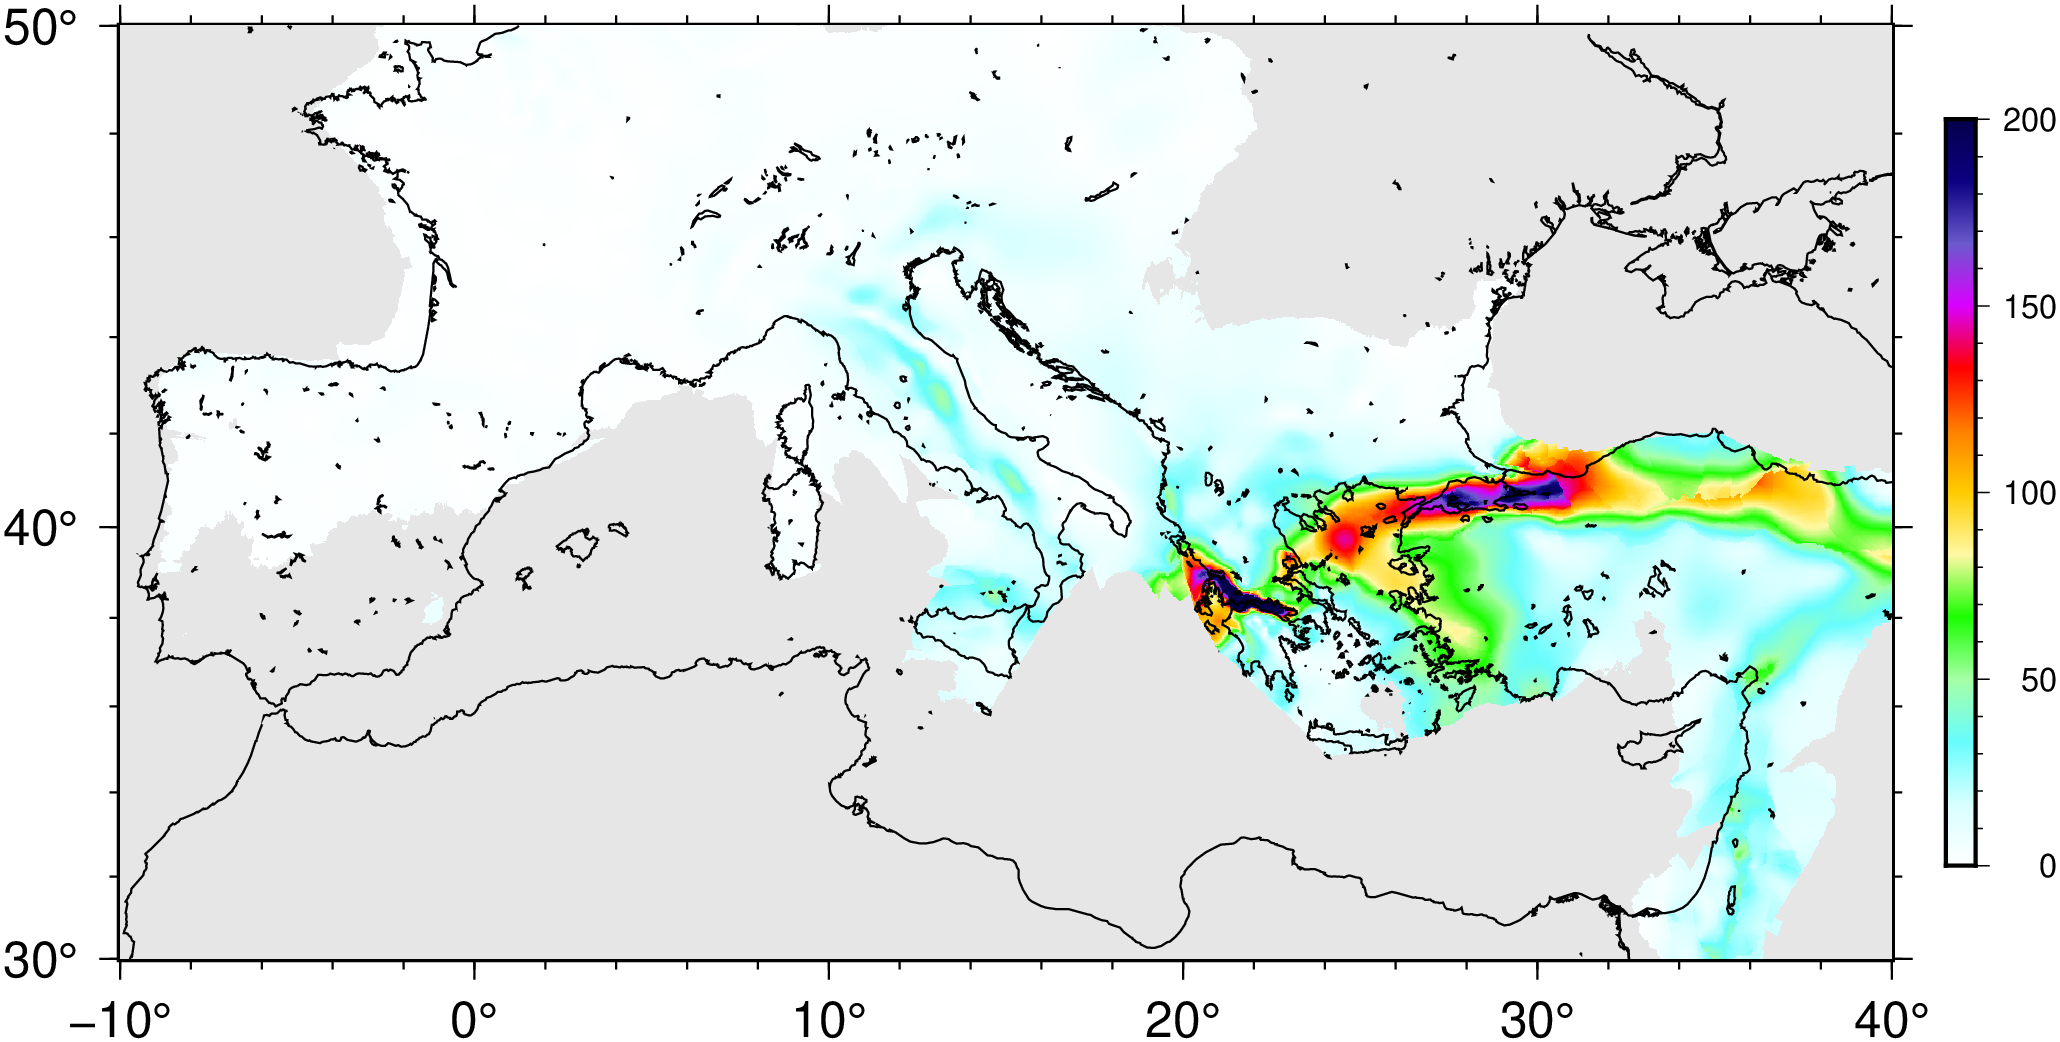

In [185]:

gmtset(MAP_FRAME_TYPE="plain", PROJ_LENGTH_UNIT="c")
cpt = makecpt(cmap="./STRrate.cpt", range="0/200")
GMT.basemap(region=region,J="M15c")
GMT.grdimage!("./ESecondInvariantFORTRAN.nc", cmap=cpt)
GMT.colorbar!()
GMT.coast!(show=true)

In [186]:
GU.write_to_netcdf("./RediualSecondInv.nc",Lon,Lat,ESecondInvariantFORTRAN .- I2_matrix)#nstr/yr

2001×801 Matrix{Float64}:
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  …  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  …  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
   ⋮                        ⋮            ⋱         ⋮                        ⋮
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  Na

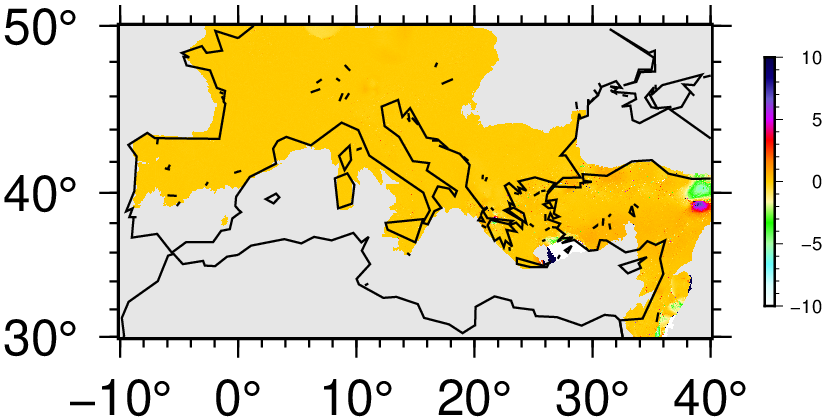

In [188]:

gmtset(MAP_FRAME_TYPE="plain", PROJ_LENGTH_UNIT="c")
cpt = makecpt(cmap="./STRrate.cpt", range="-10/10")
GMT.basemap(region=region,J="M5c")
GMT.grdimage!("./RediualSecondInv.nc", cmap=cpt)
GMT.colorbar!()
GMT.coast!(show=true)

In [189]:
Chi_vec=Float64[]
for i=1:length(results)
    if(results[i].status == 0)
        Chi=results[i].chisq
    else
        Chi=NaN
    end
    push!(Chi_vec,Chi)
end

Chi_matrix=reshape(Chi_vec,length(lon_unique),length(lat_unique))


GU.write_to_netcdf("./Chi.nc",lon_unique,lat_unique,Chi_matrix)#nstr/yr

2001×801 Matrix{Float64}:
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  …  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  …  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
   ⋮                        ⋮            ⋱         ⋮                        ⋮
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  Na

In [190]:
GU.write_to_netcdf("./ChiFORTRAN.nc",Lon,Lat,output.chisq)#nstr/yr

GU.write_to_netcdf("./ChiDIFF.nc",Lon,Lat,output.chisq .- Chi_matrix)#nstr/yr

2001×801 Matrix{Float64}:
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  …  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  …  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
   ⋮                        ⋮            ⋱         ⋮                        ⋮
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  Na

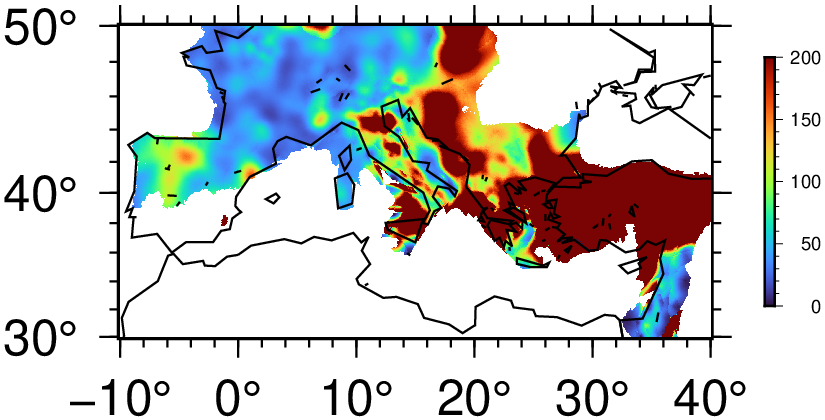

In [199]:
gmtset(MAP_FRAME_TYPE="plain", PROJ_LENGTH_UNIT="c")
cpt = makecpt(cmap="turbo", range="0/200", D="o")
GMT.basemap(region=region,J="M5c")
GMT.grdimage!("./Chi.nc", cmap=cpt)
GMT.colorbar!()
GMT.coast!(show=true)

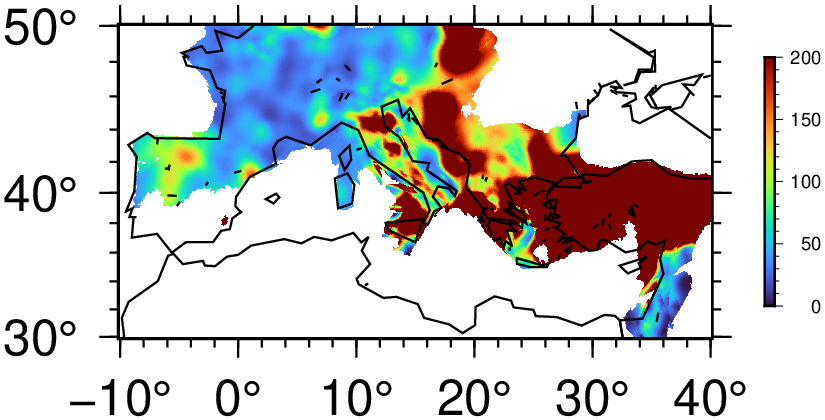

In [197]:
gmtset(MAP_FRAME_TYPE="plain", PROJ_LENGTH_UNIT="c")
cpt = makecpt(cmap="turbo", range="0/200", D="o")
GMT.basemap(region=region,J="M5c")
GMT.grdimage!("./ChiFORTRAN.nc", cmap=cpt)
GMT.colorbar!()
GMT.coast!(show=true)

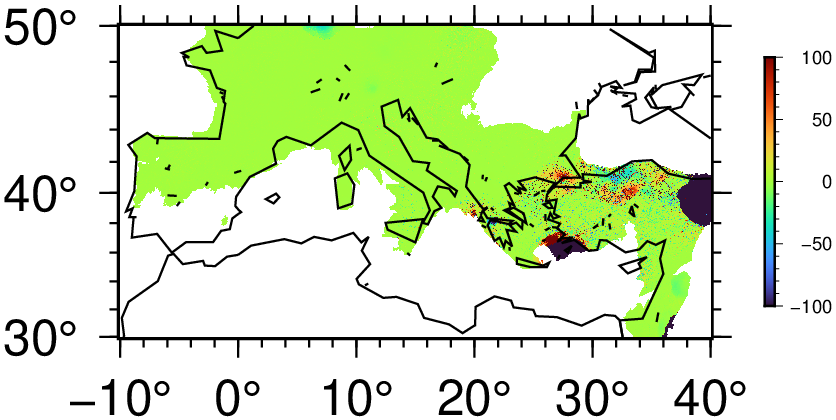

In [206]:
gmtset(MAP_FRAME_TYPE="plain", PROJ_LENGTH_UNIT="c")
cpt = makecpt(cmap="turbo", range="-100/100", D="o")
GMT.basemap(region=region,J="M5c")
GMT.grdimage!("./ChiDIFF.nc", cmap=cpt)
GMT.colorbar!()
GMT.coast!(show=true)

In [195]:
maximum(output.chisq[.!isnan.(output.chisq[:])])

33443.19

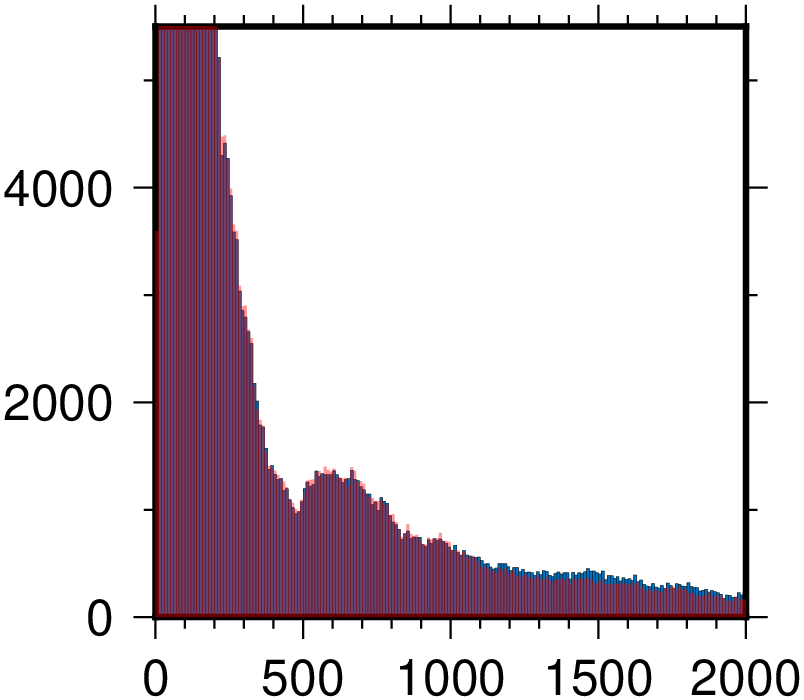

In [196]:
GMT.histogram(output.chisq[:],region=[0,2000,0,5500], bin=10, J="X5c")
GMT.histogram!(Chi_matrix[:],region=[0,2000,0,5500], bin=10, fill="red@60", show=true)

In [ ]:
output.areas

FieldError: FieldError: type NamedTuple has no field `area`, available fields: `lons`, `lats`, `longrid`, `latgrid`, `vx`, `dvx`, `vy`, `dvy`, `cxy`, `w`, `dw`, `exx`, `dexx`, `exy`, `dexy`, `eyy`, `deyy`, `emax`, `demax`, `emin`, `demin`, `shr`, `dshr`, `azi`, `dazi`, `dilat`, `ddilat`, `dis`, `weight`, `chisq`, `nsite`, `index_masks`

In [72]:
maximum(DataSet[:,7])

3.26